# Real-time Communication

In [1]:
import networkx as nx 
from dataXplorer import JupyterClient
from dataXplorer import AnalysisToolkit, SessionManager, TextureGenerator, ProjectFileManager, VisualizerSyncer

In [2]:
# run backend (server) using buildandrun powershell script
client = JupyterClient()

#client.disconnect()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [2]:
# get current directory
import os 
current_directory = os.getcwd()
print("Current Directory:", current_directory)

Current Directory: /Users/chris/Desktop/Github/DataDiVR_WebApp


### SOCIAL NETWORKS

In [3]:
# from temp-files/historynetworks/data/Social Netwokr Mulilyer Byzantine Elite 14th Century read xml file 
project_path = "temp-files/historynetworks/data/Social Network Multilayer Byzantine Elite 14th Century/Test locat 2-network-Location x Location - Shared Agent.csv"
project_name = "SocialNetwork_ByzantineElite_14thCentury"

In [4]:
# read csv to dataframe
import pandas as pd
df_raw = pd.DataFrame(pd.read_csv(project_path))
df_raw

,Source Node Name,Target Node Name,Link Value
0,Chioggia/Venetien,Methone/SW-Peloponnes,1.0
1,Chioggia/Venetien,Negroponte,1.0
2,Chioggia/Venetien,Venice,1.0
3,Chioggia/Venetien,Tenedos,1.0
4,Chioggia/Venetien,Rhodos,1.0
...,...,...,...
4427,Avlona,Serrhai,2.0
4428,Avlona,Kanina/Albanien,2.0
4429,Avlona,Tetovo/NW-Makedonien,1.0
4430,Garella,Constantinople,1.0


In [5]:
# make edgelist from df_raw
edgelist = []
for index, row in df_raw.iterrows():
    source = row['Source Node Name']
    target = row['Target Node Name']
    weight = float(row['Link Value'])
    edgelist.append((source, target, weight))

print("Edgelist created with", len(edgelist), "edges.")

Edgelist created with 4432 edges.


In [6]:
edgelist

[('Chioggia/Venetien', 'Methone/SW-Peloponnes', 1.0),
 ('Chioggia/Venetien', 'Negroponte', 1.0),
 ('Chioggia/Venetien', 'Venice', 1.0),
 ('Chioggia/Venetien', 'Tenedos', 1.0),
 ('Chioggia/Venetien', 'Rhodos', 1.0),
 ('Chioggia/Venetien', 'Famagusta', 1.0),
 ('Kasos', 'Karpathos', 1.0),
 ('Kasos', 'Genoa', 1.0),
 ('Kasos', 'Candia', 1.0),
 ('Kasos', 'Constantinople', 1.0),
 ('Kasos', 'Kallipolis', 1.0),
 ('Kasos', 'Tenedos', 1.0),
 ('Kasos', 'Madyta/Thrakien', 1.0),
 ('Kasos', 'Rhodos', 1.0),
 ('Kasos', 'Famagusta', 1.0),
 ('Vidin/Donau', 'Adrianople', 1.0),
 ('Vidin/Donau', 'Sebasteia', 1.0),
 ('Vidin/Donau', 'Kallipolis', 1.0),
 ('Vidin/Donau', 'Nikopolis/Donau', 1.0),
 ('Vidin/Donau', 'Silistria/Donau', 1.0),
 ('Vidin/Donau', 'Velbuzd (Kjustendil/W-Bulgarien)', 2.0),
 ('Vidin/Donau', 'Wallachia', 1.0),
 ('Vidin/Donau', 'Ankara', 1.0),
 ('Vidin/Donau', 'Constantinople', 1.0),
 ('Vidin/Donau', 'Gomneck (Humnek bei Zagreb)', 1.0),
 ('Vidin/Donau', 'Ikonion', 1.0),
 ('Vidin/Donau', 'Prus

In [7]:
# check for duplicates in edgelist
seen_edges = set()
duplicates = []
for edge in edgelist:
    edge_pair = (edge[0], edge[1])
    if edge_pair in seen_edges:
        duplicates.append(edge)
    else:
        seen_edges.add(edge_pair)
        
print("Found", len(duplicates), "duplicate edges.")

Found 0 duplicate edges.


In [8]:
# check for directionality in edgelist
directed_count = 0
for edge in edgelist:
    reverse_edge = (edge[1], edge[0], edge[2])
    if reverse_edge in edgelist:
        directed_count += 1
print("Found", directed_count, "directed edge pairs.")

Found 4432 directed edge pairs.


In [9]:
G = nx.Graph() # ignoring directionality for now - as all edges are bidirectional
G.add_weighted_edges_from(edgelist)
print("Graph loaded with", G.number_of_nodes(), "nodes and", G.number_of_edges(), "edges.")

Graph loaded with 319 nodes and 2216 edges.


In [10]:
import cartoGRAPHs as cg
pos_3D = cg.layout_global_umap(G, dim=3, n_neighbors=10, min_dist=0.1)
pos_3D_ = {key: list(value) for key, value in pos_3D.items()}

/Users/chris/Desktop/Github/DataDiVR_WebApp/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/chris/Desktop/Github/DataDiVR_WebApp/venv/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/chris/Desktop/Github/DataDiVR_WebApp/venv/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels

In [11]:
G.graph['projectname'] = "ByzNet-1400"
G.graph['info'] = "ByzNet-1400 visualises the multi-layered social, political, and kinship networks of the Late Byzantine elite " \
"(1282–1402 CE) using data derived from the PLP prosopography. The dataset connects 2402 individuals and 336 localities across ties of kinship, " \
"allegiance, friendship, conflict, diplomacy, and mobility, revealing how elite factions formed, fractured, " \
"and interacted during a period of civil war and imperial contraction. The project constructs a multiplex, temporal, " \
"and geospatial graph, enabling exploration of power clusters, conflict dynamics, family expansion, and the central role " \
"of Constantinople within a highly interconnected but increasingly polarised aristocratic world."

G.graph["layoutname"] ='layout-3D'
nx.set_node_attributes(G, pos_3D_, name='pos')

In [12]:
import nx2json as nx2j 
nx2j.create_project(G)

Successfully created the directory static/projects/ByzNet-1400 
PROGRESS: loaded graph JSON...
PROGRESS: stored graph data...
PROGRESS: stored layouts...
PROGRESS: stored node info...
PROGRESS: made node position textures...
PROGRESS: made textures for node colors...
PROGRESS: made textures for links...
PROGRESS: no linkcolors detected for  layout-3D
PROGRESS: writing json files for project and nodes...
Project created successfully.


In [13]:
# visualization idea
# globe with road map
# 3rd dimension: a circle of points surrounding a city/node, gets a height for a parameter (e.g., population, trade volume, etc.)
# color code 

### Dataset "Social byzantine 14th century" : "Only people"

In [14]:
import networkx as nx
import xml.etree.ElementTree as ET

def create_people_multiplex_graph_from_file(file_path):
    """
    Transforms the social network data from an XML file into a NetworkX MultiGraph.
    Nodes are people, and multiple edges (relationships) are allowed between them.

    Args:
        file_path (str): The path to the XML file ('Only People.xml').

    Returns:
        networkx.MultiGraph: The constructed multiplex social network graph.
    """
    G = nx.MultiGraph()
    people_data = {}
    relationship_tags = set()
    
    try:
        # Read content directly from the file path
        tree = ET.parse(file_path)
        root = tree.getroot()
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}. Please ensure the file is correctly provided.")
        return G
    except ET.ParseError as e:
        print(f"Error: Could not parse XML file at {file_path}. Error: {e}")
        return G

    # 1. First Pass: Find all nodes (people) and add them
    # The structure is DynamicMetaNetwork > MetaNetwork > nodes > nodeclass > node
    nodes_section = root.find('.//nodes/nodeclass[@type="Agent"]')
    if nodes_section is None:
        print("No Agent nodes found in the XML structure.")
        return G

    for node_elem in nodes_section.findall('node'):
        person_id = node_elem.get('id')
        if person_id:
            # Extract properties for each person
            person_name = person_id  # Use ID as default name
            properties = {}
            
            for prop in node_elem.findall('property'):
                prop_id = prop.get('id')
                prop_value = prop.get('value')
                if prop_id and prop_value:
                    properties[prop_id] = prop_value
                    
                    # Use 'Node Title' as name if available, otherwise keep ID
                    if prop_id == 'Node Title':
                        person_name = prop_value
            
            # Add node with all properties
            people_data[person_id] = {'id': person_id, 'name': person_name, **properties}
            G.add_node(person_id, label=person_name, **properties)

    # 2. Second Pass: Add edges (relationships) from the networks section
    networks_section = root.find('.//networks/network')
    if networks_section is not None:
        for link_elem in networks_section.findall('link'):
            source_id = link_elem.get('source')
            target_id = link_elem.get('target')
            
            # Get link attributes like weight if available
            link_attrs = {}
            for attr_name, attr_value in link_elem.attrib.items():
                if attr_name not in ['source', 'target']:
                    link_attrs[attr_name] = attr_value
            
            # Only add edge if both nodes exist in our graph
            if source_id and target_id and source_id in G and target_id in G:
                # Add the edge with any additional attributes
                G.add_edge(source_id, target_id, **link_attrs)
                relationship_tags.add('social_connection')  # Generic relationship type

    print("--- Multiplex Graph Summary ---")
    print(f"Total Nodes: {G.number_of_nodes()}")
    print(f"Total Edges: {G.number_of_edges()}")
    print(f"Sample node properties: {list(people_data.keys())[:5] if people_data else 'None'}")
    print(f"Relationship Types: {relationship_tags}")
    
    return G

In [15]:
path_onlypeople = "temp-files/historynetworks/data/Social Network Multilayer Byzantine Elite 14th Century/Only People.xml"
people_multiplex_graph = create_people_multiplex_graph_from_file(path_onlypeople)

--- Multiplex Graph Summary ---
Total Nodes: 856
Total Edges: 2234
Sample node properties: ['Ααρὼν Αλέξιος', 'Αβράμιος Μανουήλ', 'Αδριανός, Πέτρος Δούκας', 'Αγγελος Μανουήλ', '<Αγγελος>, Νικηφόρος ΙΙ. Δούκας']
Relationship Types: {'social_connection'}


In [16]:
import cartoGRAPHs as cg
pos_3D_people = cg.layout_global_umap(people_multiplex_graph, dim=3, n_neighbors=10, min_dist=0.1)
pos_3D_people_ = {key: list(value) for key, value in pos_3D_people.items()}

/Users/chris/Desktop/Github/DataDiVR_WebApp/venv/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [17]:
people_multiplex_graph.graph['projectname'] = "ByzNet-1400-people-only"
people_multiplex_graph.graph['info'] = "ByzNet-1400 visualises the multi-layered social, political, and kinship networks of the Late Byzantine elite " \
"(1282–1402 CE) using data derived from the PLP prosopography. The dataset connects 2402 individuals and 336 localities across ties of kinship, " \
"allegiance, friendship, conflict, diplomacy, and mobility, revealing how elite factions formed, fractured, " \
"and interacted during a period of civil war and imperial contraction. The project constructs a multiplex, temporal, " \
"and geospatial graph, enabling exploration of power clusters, conflict dynamics, family expansion, and the central role " \
"of Constantinople within a highly interconnected but increasingly polarised aristocratic world."

people_multiplex_graph.graph["layoutname"] ='layout-3D'
nx.set_node_attributes(people_multiplex_graph, pos_3D_people_, name='pos')

In [18]:
import nx2json as nx2j 
nx2j.create_project(G)

Successfully created the directory static/projects/ByzNet-1400 
PROGRESS: loaded graph JSON...
PROGRESS: stored graph data...
PROGRESS: stored layouts...
PROGRESS: stored node info...
PROGRESS: made node position textures...
PROGRESS: made textures for node colors...
PROGRESS: made textures for links...
PROGRESS: no linkcolors detected for  layout-3D
PROGRESS: writing json files for project and nodes...
Project created successfully.


### Data set  "Social byzantine 14th century" : "People and Locations"

In [31]:
import networkx as nx 
def create_people_and_locations_graph_from_file(file_path):
    """
    Parse a "People and locations" XML (same structure as "Only People.xml") into a NetworkX Graph.
    Nodes: all nodeclasses (e.g., Agent, Location) with their properties. Node label uses 'Node Title' if present.
    Edges: all link elements from networks/network sections. Each edge receives link attributes and a 'layer' attribute.

    Returns:
        networkx.Graph: simple graph (no parallel edges) built from the XML.
    """
    G = nx.Graph()
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()
    except FileNotFoundError:
        print(f"Error: File not found: {file_path}")
        return nx.Graph()
    except ET.ParseError as e:
        print(f"Error parsing XML {file_path}: {e}")
        return nx.Graph()

    # Parse nodes from all nodeclass entries under nodes
    for nodeclass in root.findall('.//nodes/nodeclass'):
        ntype = nodeclass.get('type') or 'unknown'
        for node_elem in nodeclass.findall('node'):
            nid = node_elem.get('id')
            if not nid:
                continue
            props = {}
            label = nid
            for prop in node_elem.findall('property'):
                pid = prop.get('id')
                pval = prop.get('value')
                if pid and pval:
                    props[pid] = pval
                    if pid == 'Node Title':
                        label = pval
            props['type'] = ntype
            G.add_node(nid, label=label, **props)

    # Parse links from all networks (keep network id/name as edge layer)
    for network in root.findall('.//networks/network'):
        layer = network.get('id') or network.get('name') or 'network'
        for link in network.findall('link'):
            s = link.get('source')
            t = link.get('target')
            if not s or not t:
                continue
            # collect link attributes (exclude source/target)
            edge_attrs = {k: v for k, v in link.attrib.items() if k not in ('source', 'target')}
            edge_attrs['layer'] = layer
            # ensure nodes exist (create minimal node if missing)
            if s not in G:
                G.add_node(s, label=s, type='unknown')
            if t not in G:
                G.add_node(t, label=t, type='unknown')
            # add or update edge attributes (Graph will keep one edge per node-pair)
            if G.has_edge(s, t):
                # merge attributes if edge already exists: prefer existing, but update with any new keys
                existing = G[s][t]
                merged = dict(existing)
                merged.update(edge_attrs)
                G[s][t].update(merged)
            else:
                G.add_edge(s, t, **edge_attrs)

    # Summary
    from collections import Counter
    types = [data.get('type', 'unknown') for _, data in G.nodes(data=True)]
    type_counts = Counter(types)
    print("--- People & Locations Graph Summary ---")
    print(f"Total nodes: {G.number_of_nodes()} (by type: {dict(type_counts)})")
    print(f"Total edges: {G.number_of_edges()}")

    # Ensure we return a simple nx.Graph object
    if not isinstance(G, nx.Graph):
        H = nx.Graph()
        for n, data in G.nodes(data=True):
            H.add_node(n, **data)
        for u, v, data in G.edges(data=True):
            H.add_edge(u, v, **data)
        G = H

    return G

In [41]:
path_peopleandlocations = "temp-files/historynetworks/data/Social Network Multilayer Byzantine Elite 14th Century/People and locations.xml" 
people_location_graph = create_people_and_locations_graph_from_file(path_peopleandlocations)

--- People & Locations Graph Summary ---
Total nodes: 2735 (by type: {'Agent': 2399, 'Location': 336})
Total edges: 8095


In [42]:
from datetime import datetime
import math

# parse localities file and build location_positions (safe to rebuild)
path_locations = "temp-files/historynetworks/data/Social Network Multilayer Byzantine Elite 14th Century/Localities network total.xml"
tree_loc = ET.parse(path_locations)
root_loc = tree_loc.getroot()
location_positions = {}
for nodeclass in root_loc.findall('.//nodes/nodeclass'):
    if nodeclass.get('type') != 'Location':
        continue
    for node_elem in nodeclass.findall('node'):
        nid = node_elem.get('id')
        if not nid:
            continue
        lat = lon = None
        for prop in node_elem.findall('property'):
            pid = prop.get('id')
            pval = prop.get('value')
            if pid == 'Latitude':
                try:
                    lat = float(pval)
                except (TypeError, ValueError):
                    lat = None
            elif pid == 'Longitude':
                try:
                    lon = float(pval)
                except (TypeError, ValueError):
                    lon = None
        if lat is not None and lon is not None:
            # convert lon/lat (degrees) to ECEF cartesian coordinates (meters)
            R = 6371000.0  # mean Earth radius in meters
            lon_r = math.radians(lon)
            lat_r = math.radians(lat)
            x = R * math.cos(lat_r) * math.cos(lon_r)
            y = R * math.cos(lat_r) * math.sin(lon_r)
            z = R * math.sin(lat_r)
            location_positions[nid] = [x, y, z]

# normalize ECEF coordinates to 0-1 range per axis
normalized_positions = {}
if location_positions:
    xs = [p[0] for p in location_positions.values()]
    ys = [p[1] for p in location_positions.values()]
    zs = [p[2] for p in location_positions.values()]
    minx, maxx = min(xs), max(xs)
    miny, maxy = min(ys), max(ys)
    minz, maxz = min(zs), max(zs)
    dx = maxx - minx
    dy = maxy - miny
    dz = maxz - minz

    for nid, (x, y, z) in location_positions.items():
        nx = (x - minx) / dx if dx > 0 else 0.5
        ny = (y - miny) / dy if dy > 0 else 0.5
        nz = (z - minz) / dz if dz > 0 else 0.5
        normalized_positions[nid] = [nx, ny, nz]
else:
    print("No location positions found to normalize.")

# assign positions with checks for existing pos and timestamp metadata
added = 0
skipped = 0
updated_with_no_timestamp = []

for node_id, ecef_pos in location_positions.items():
    if node_id not in people_location_graph:
        continue
    node_attrs = people_location_graph.nodes[node_id]
    norm_pos = normalized_positions.get(node_id, [0.5, 0.5, 0.5])
    people_location_graph.nodes[node_id]['pos'] = norm_pos
    print(f"ADD  {node_id}: pos set to {norm_pos}")
    added += 1

print(f"Summary: added={added}, skipped={skipped}, preexisting_marked={len(updated_with_no_timestamp)}")

ADD  Constantinople: pos set to [0.7371133954829452, 0.5299324649050993, 0.495747965002846]
ADD  Moscow: pos set to [0.2967978452787541, 0.4997233740396006, 0.9699178013456295]
ADD  Alexandria: pos set to [0.903621050590961, 0.6137173388197763, 0.11189536132210628]
ADD  Lesbos: pos set to [0.806922265248911, 0.5043697573791299, 0.4249710142951941]
ADD  Thessalonike: pos set to [0.8161192894896181, 0.43461201392210913, 0.4824475066413095]
ADD  Gratianupolis/Thrakien: pos set to [0.7767652460506541, 0.4737388636763318, 0.5009035189255945]
ADD  Kastoria: pos set to [0.8363371253176478, 0.4067871270842517, 0.47765269029148966]
ADD  Trikala: pos set to [0.8517552186737859, 0.42089034254064916, 0.44203116394704106]
ADD  Didymoteichon: pos set to [0.7611904839339042, 0.4878808956536358, 0.50816551186946]
ADD  Rome: pos set to [0.8742534442839667, 0.2494380462846055, 0.5275695802903553]
ADD  Arta: pos set to [0.8684266981503365, 0.40950193958943426, 0.4266663159257931]
ADD  Kephallenia: pos se

In [43]:
# check which nodes in people_location_graph have pos attribute
nodes_with_pos = [n for n, attrs in people_location_graph.nodes(data=True) if 'pos' in attrs]
print(f"Nodes with 'pos' attribute: {len(nodes_with_pos)} out of {  people_location_graph.number_of_nodes()} total nodes.") 


Nodes with 'pos' attribute: 308 out of 2735 total nodes.


In [44]:
people_location_graph.nodes(data=True)

NodeDataView({'Ααρὼν Αλέξιος': {'label': 'Ααρὼν Αλέξιος', 'Function': 'Gesandter', 'Rank': 'Oikeios', 'Begin': '1393.0', 'End': '1393', 'PLP': '3.0', 'Secular/Ecclesiastical': 'Sec', 'type': 'Agent'}, 'Αβράμιος Ιωάννης': {'label': 'Αβράμιος Ιωάννης', 'Function': 'Astrologe in Kpl, 1371 - 1390; Priester (?), vor 1371-05; Hs.-Schreiber, 1376 - 1381, Schriftsteller, Arzt', 'Begin': '1371.0', 'End': '1391.0', 'PLP': '57.0', 'Secular/Ecclesiastical': 'Sec', 'type': 'Agent'}, 'Αβράμιος Μανουήλ': {'label': 'Αβράμιος Μανουήλ', 'Function': 'δοῦλος d. Παλαιολόγος Ανδρόνικος ΙΙΙ., gegen den er sich verschworen hatte.', 'Rank': 'Doulos', 'Begin': '1336.0', 'End': '1336', 'PLP': '58.0', 'Secular/Ecclesiastical': 'Sec', 'type': 'Agent'}, 'Αγάθων Μανουήλ': {'label': 'Αγάθων Μανουήλ', 'Function': 'Senator in Kpl, 1409', 'Rank': 'Oikeios', 'Begin': '1402.0', 'End': '1402', 'PLP': '88.0', 'Secular/Ecclesiastical': 'Sec', 'type': 'Agent'}, 'Αγάλλων Μανουήλ': {'label': 'Αγάλλων Μανουήλ', 'Function': 'δοῦλ

In [48]:
import networkx as nx 

# make a spring layout for people_location_graph but keep location nodes fixed
fixed_nodes = [n for n, attrs in people_location_graph.nodes(data=True) if attrs.get('type') == 'Location' and 'pos' in attrs]
# build a pos dict for the fixed nodes (use their existing 'pos' attribute) and anchor them in the layout
pos_fixed = {n: tuple(people_location_graph.nodes[n]['pos']) for n in fixed_nodes if 'pos' in people_location_graph.nodes[n]}

pos_spring = nx.spring_layout(
    people_location_graph,
    dim=3,
    pos=pos_fixed,
    fixed=list(pos_fixed.keys()),
    iterations=100,
    seed=42
)

In [52]:
people_location_graph.graph['projectname'] = "ByzNet-1400-people-and-locations"
people_location_graph.graph['info'] = "ByzNet-1400 visualises the multi-layered social, political, and kinship networks of the Late Byzantine elite " \
"(1282–1402 CE) using data derived from the PLP prosopography. The dataset connects 2402 individuals and 336 localities across ties of kinship, " \
"allegiance, friendship, conflict, diplomacy, and mobility, revealing how elite factions formed, fractured, " \
"and interacted during a period of civil war and imperial contraction. The project constructs a multiplex, temporal, " \
"and geospatial graph, enabling exploration of power clusters, conflict dynamics, family expansion, and the central role " \
"of Constantinople within a highly interconnected but increasingly polarised aristocratic world."

people_location_graph.graph["layoutname"] ='layout-3D'
nx.set_node_attributes(people_location_graph, pos_3D_people_, name='pos')

In [58]:
# node colors 

nodecolor = []
for n, attrs in people_location_graph.nodes(data=True):
    if attrs.get('type') == 'Agent':
        nodecolor.append((0, 0, 255, 200))  # blue for people
    elif attrs.get('type') == 'Location':
        nodecolor.append((255, 0, 0, 200))  # red for locations

# set as node attribute
nx.set_node_attributes(people_location_graph, {n: color for n, color in zip(people_location_graph.nodes(), nodecolor)}, name='nodecolor')

# link colors 
linkcolor = []
for u, v, attrs in people_location_graph.edges(data=True):
    layer = attrs.get('layer', '')
    if 'kinship' in layer.lower():
        linkcolor.append((0, 255, 0, 200))  # green for kinship
    elif 'friendship' in layer.lower():
        linkcolor.append((0, 0, 255, 200))  # blue for friendship
    elif 'conflict' in layer.lower():
        linkcolor.append((255, 0, 0, 200))  # red for conflict
    else:
        linkcolor.append((128, 128, 128, 60))  # gray for other

# set as edge attribute
nx.set_edge_attributes(people_location_graph, { (u, v): color for (u, v), color in zip(people_location_graph.edges(), linkcolor)}, name='linkcolor')

In [59]:
import nx2json as nx2j 
nx2j.create_project(people_location_graph)

Successfully created the directory static/projects/ByzNet-1400-people-and-locations 
PROGRESS: loaded graph JSON...
PROGRESS: stored graph data...
PROGRESS: stored layouts...
PROGRESS: stored node info...
PROGRESS: made node position textures...
PROGRESS: made textures for node colors...
PROGRESS: made textures for links...
PROGRESS: made textures for linkcolors...
PROGRESS: writing json files for project and nodes...
Project created successfully.


### Access Project list and select one by ID

In [3]:
# see if new project is in projectlist
import GlobalData as GD

allprojects_updated = []
for i, proj in enumerate(GD.listProjects()):
    allprojects_updated.append((i,proj))
allprojects_updated

[(0, 'CDK5'),
 (1, 'CircLadderGraph-xsmall'),
 (2, 'diffusion'),
 (3, 'JSON_autocore'),
 (4, 'JSON_barbellgraph'),
 (5, 'JSON_Zachary'),
 (6, 'Microplastics_HumanHealth'),
 (7, 'Pesticides_HumanHealth'),
 (8, 'PG_NEW'),
 (9, 'Powergrid_Europe'),
 (10, 'PPI_brain_infarction'),
 (11, 'PPI_joel_daniel_aryan'),
 (12, 'PPI_joel_daniel_aryan_test_1'),
 (13, 'PPI_networkcartoGRAPHs'),
 (14, 'Realtime-project'),
 (15, 'Sphere_Torus'),
 (16, 'Teapot'),
 (17, 'Template'),
 (18, 'test'),
 (19, 'TheMandelbulb_edges'),
 (20, 'XX')]

In [4]:
# select a project to work with
sel_id = 11
sel_name = allprojects_updated[sel_id][1]

# load the project data
session = SessionManager(sel_id, sel_name, client)
session.load_graph_from_project()
session.reload_project()

# initialize 
file_mgr = ProjectFileManager(session)
tex_gen = TextureGenerator(session)
syncer = VisualizerSyncer(session)

Session Graph loaded from project folder. 
Project name:  PPI_joel_daniel_aryan
Data: Nodes: 18176 Links: 476727


In [5]:
G = session.load_graph_from_project()

# get nodenames from node attributes
nodenames_session = [data.get("name") for _, data in G.nodes(data=True)]
nodenames_session = [name for name in nodenames_session if name is not None]

# rename nodes back to original names
mapping = dict(zip(G.nodes(), nodenames_session))
G = nx.relabel_nodes(G, mapping)
G.nodes()

Session Graph loaded from project folder. 
Project name:  PPI_joel_daniel_aryan
Data: Nodes: 18176 Links: 476727


NodeView(('CIC', 'GTPBP3', 'KLF5', 'TRIM22', 'SOX15', 'ELF4', 'ELK3', 'SETD2', 'SOX6', 'YWHAQ', 'FOXQ1', 'SOX5', 'PAX7', 'SP7', 'HNF4A', 'KLHL22', 'ERG', 'S100P', 'TEAD1', 'PICK1', 'NFIX', 'PAX6', 'SOX17', 'TLX2', 'IRF8', 'RAVER1', 'GABPB1', 'NFIC', 'YWHAB', 'GATA2', 'LHX3', 'FOS', 'EN1', 'MAD2L1', 'KLF3', 'TBXT', 'TLX3', 'PAX9', 'NFYC', 'TBR1', 'SEC62', 'LHX6', 'CENPJ', 'PRDM1', 'HNF1A', 'SOX9', 'PYCR2', 'TLX1', 'CSNK2B', 'YWHAZ', 'RAD50', 'VSX1', 'IRF4', 'LHX4', 'PAX8', 'ZBTB18', 'GATA3', 'FOXL1', 'PLK1', 'YWHAE', 'MYB', 'ESR1', 'POLR1H', 'GOLGA2', 'PAX2', 'AR', 'GCM1', 'LHX2', 'FEV', 'SOX2', 'FOXK2', 'YWHAG', 'SOX10', 'HNF1B', 'ATXN1', 'KLF12', 'KLF15', 'NFIA', 'EYA2', 'YWHAH', 'NFIB', 'KLF8', 'PRPF3', 'PPP1R18', 'ETFRF1', 'RASL10B', 'MRPL21', 'DPPA4', 'SERTAD3', 'GPR45', 'MBD3L1', 'GNE', 'TARDBP', 'PYCR1', 'AGR2', 'RALY', 'PIKFYVE', 'MEOX2', 'MESD', 'INCA1', 'BEND7', 'PTAFR', 'MGST3', 'RCN1', 'COPS5', 'YARS2', 'SPINT2', 'IMMP2L', 'ZNF774', 'CAPN3', 'RAMP2', 'PDK1', 'KLK14', 'SINHCA

### Manipulate node colors / positions / link colors 

In [6]:
# initialize analysis toolkit
tools = AnalysisToolkit(session, tex_gen, syncer, file_mgr)

In [7]:
import pandas as pd
# read gene list from csv
symbol_pep_3 = pd.read_csv('temp-files/PPI_joel/symbol_pep_3.csv', header=None)[0].tolist()
symbol_pep_11 = pd.read_csv('temp-files/PPI_joel/symbol_pep_11.csv', header=None)[0].tolist()
symbol_pep_33 = pd.read_csv('temp-files/PPI_joel/symbol_pep_33.csv', header=None)[0].tolist()
symbol_pep_54 = pd.read_csv('temp-files/PPI_joel/symbol_pep_54.csv', header=None)[0].tolist()
symbol_pep_63 = pd.read_csv('temp-files/PPI_joel/symbol_pep_63.csv', header=None)[0].tolist()
symbol_pep_66 = pd.read_csv('temp-files/PPI_joel/symbol_pep_66.csv', header=None)[0].tolist()
symbol_pep_69 = pd.read_csv('temp-files/PPI_joel/symbol_pep_69.csv', header=None)[0].tolist()
symbol_pep_71 = pd.read_csv('temp-files/PPI_joel/symbol_pep_71.csv', header=None)[0].tolist()
symbol_pep_72 = pd.read_csv('temp-files/PPI_joel/symbol_pep_72.csv', header=None)[0].tolist()
symbol_pep_75 = pd.read_csv('temp-files/PPI_joel/symbol_pep_75.csv', header=None)[0].tolist()

In [8]:
nodelist = symbol_pep_3
#temp_nodelist = ['node0', 'node1', 'node2', 'node3', 'node4', 'node5', 'node6', 'node7', 'node8']

tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name= "symbol_pep_3")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True,  scene_name= "symbol_pep_3_relayout")


C_DEBUG: sub_nodes: ['ATAD2', 'ZC3H13', 'CNRIP1', 'ZSCAN22', 'VIM', 'CYBRD1', 'POLE2', 'GMCL1', 'SMAP1', 'CLCA4', 'TPT1', 'TAOK2', 'HIF3A', 'USP32', 'SFRP4', 'ZNF670', 'EFS', 'SMARCB1', 'PRR3', 'GTF3C5', 'LAMB1', 'INHBB', 'NCAPD2', 'TBC1D25', 'BHLHE40', 'MID1', 'PPP1R14C', 'STARD13', 'ZNF165', 'ZNF226', 'HS2ST1', 'LGALSL', 'GPRASP1', 'NPTXR', 'PEAR1', 'ANTKMT', 'NT5E', 'C2orf49', 'OVGP1', 'PROM1', 'PRDM5', 'CADM3-AS1', 'SLC37A2', 'N4BP2L2', 'CCDC43', 'HSPB8', 'CD2BP2-DT', 'RBMXL1', 'LINC00963', 'PTGIS', 'IGF2', 'SVBP', 'NUP155', 'E2F3', 'ERCC4', 'TACR1', 'INPP4A', 'PRRG3', 'ZSCAN9', 'TDP1', 'HMGN5', 'COL17A1', 'BCL7C', 'MAN1B1', 'CCHCR1', 'POLE', 'SLCO2A1', 'MBOAT1', 'ATXN2L', 'OPA3', 'PDLIM5', 'NAA38', 'NDUFB6', 'AKR1B1', 'MED25', 'AXL', 'LAMA5', 'TRMT10A', 'C6orf89', 'MRPS7', 'ABCC2', 'USP3', 'MIATNB', 'SSC5D', 'UBE2T', 'FANCI', 'GYS1', 'UBAC1', 'MRGPRF', 'TMT1A', 'TNKS1BP1', 'GPR155', 'LRRCC1', 'GBF1', 'MCUB', 'TCF21', 'SRRM2', 'SMAD6', 'DCTD', 'EMP2', 'CRYZL2P', 'CD34', 'TIGD6', 'P

C_DEBUG: sub_nodes: ['RAD51C', 'SALL4', 'ZNF681', 'SMOC1', 'TANC1', 'ZNF830', 'PSPN', 'ACP2', 'EFCAB11', 'UBQLN1-AS1', 'MYLK3', 'FER1L5', 'ZNF408', 'SNORA73B', 'VPS33A', 'FAM50B', 'ACTN2', 'DOLK', 'SNAPIN', 'PLEKHG5', 'GPD1L', 'TRPV3', 'ENPEP', 'NSUN7', 'GALNT18', 'COPZ2', 'FAM161B', 'SMG8', 'B3GNT3', 'SREBF2-AS1', 'TUBA1B-AS1', 'KAZN', 'DGKD', 'KLRG1', 'FLG', 'IGSF10', 'CHAMP1', 'SIGLEC6', 'KIT', 'SLC18A2', 'PZP', 'MOCS3', 'A2M', 'SPATA33', 'TRMT10A', 'ATP2B2', 'RNF139-DT', 'AFAP1-AS1', 'GPC5', 'SOCS2-AS1', 'HSD17B1-AS1', 'CSRP1-AS1', 'PGC', 'FGGY', 'MED11', 'MPDU1-AS1', 'MED12L', 'PSPH', 'EIF3J-DT', 'ZNF468', 'MUC16', 'MED19', 'FUCA1', 'ESYT2', 'NUAK2', 'SLC52A1', 'HSPD1P11', 'KMO', 'ZNF300P1', 'ZNF837', 'H2BC17', 'NKX3-1', 'ZSWIM1', 'SHANK1', 'CATSPERG', 'ZNG1E', 'ZCCHC3', 'ABCG1']
C_DEBUG: sub_nodes_ids: [527, 1143, 1294, 1529, 1972, 2569, 3001, 3537, 3658, 4484, 4486, 4559, 4562, 4888, 5704, 5889, 5986, 6117, 6233, 6507, 6706, 7029, 7663, 7740, 7949, 8004, 8019, 8446, 8528, 8562, 

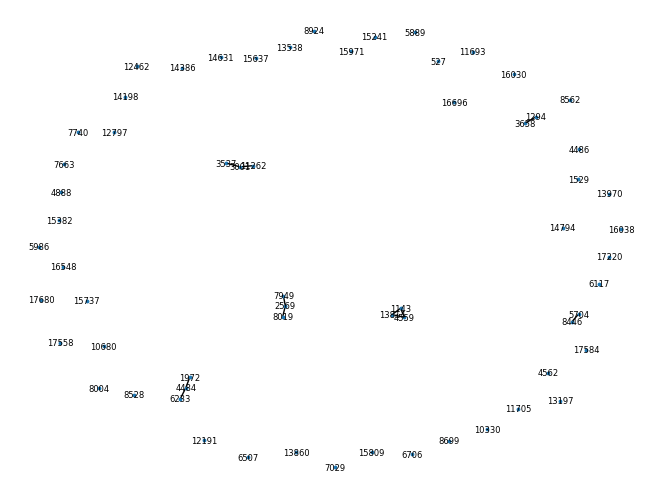

In [62]:
nodelist = symbol_pep_11
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_11")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_11_relayout")

C_DEBUG: sub_nodes: ['NPR1', 'AIF1L', 'HAUS5', 'GIMAP1', 'MCM6', 'ZNF699', 'CYBRD1', 'ZMYM3', 'SORCS2', 'SETDB2', 'TRDMT1', 'PAF1', 'SUPT5H', 'CASTOR3P', 'EDN2', 'ACVR1', 'ADK', 'NINJ2-AS1', 'NR1H2', 'JMY', 'ABCC1', 'VWA1', 'PCAT19', 'RUNX2', 'ANKRD27', 'EIF2AK1', 'EEIG1', 'CPED1', 'LINC01278', 'AMER1', 'YIF1B', 'KCNS1', 'SESN1', 'REEP4', 'PRPF3', 'MTURN', 'MFSD6', 'STPG1', 'C2orf88', 'NRG2', 'GAA', 'FGF10', 'MOSMO', 'POLR3D', 'RGL2', 'TACC3', 'ATE1', 'MXRA8', 'SCNN1B', 'ZNHIT6', 'BUB1', 'ZNF480', 'CFAP69', 'RBM42', 'NCCRP1', 'PLXNA3', 'MMP13', 'HSPBP1', 'IFI6', 'CNTNAP2', 'PTPN21', 'CTSF', 'PTGIS', 'AMIGO2', 'COX6B1', 'CDKN3', 'SMC1A', 'GALNS', 'UBE2S', 'EXOSC10', 'FAM135A', 'GGACT', 'OSR1', 'COL11A1', 'CDK16', 'EXO1', 'BIVM', 'EPHB2', 'ZNF444', 'RNF144B', 'PLK1', 'CCDC97', 'MFAP2', 'TIMM50', 'CREBL2', 'NEK2', 'ABTB1', 'BRIP1', 'UBE2T', 'FAF2', 'FAM83D', 'CCDC106', 'SCUBE1', 'MRGPRF', 'LSM1', 'HOXA-AS2', 'TMT1A', 'ATAD3A', 'SYNJ2BP', 'NEFH', 'PLPP5', 'ZC2HC1A', 'GSR', 'DDX41', 'PFKFB4

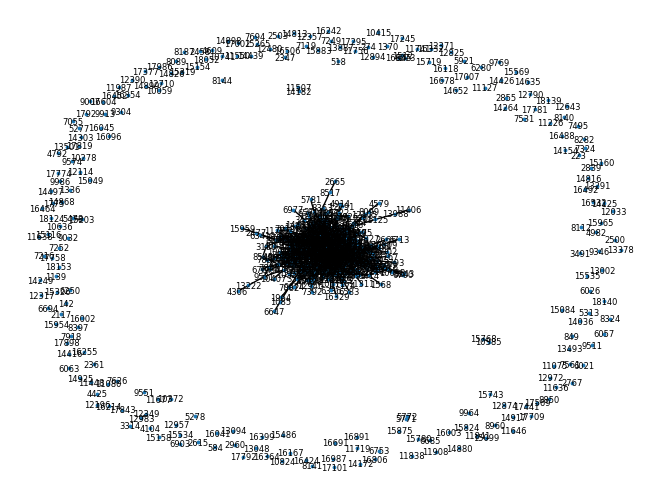

In [9]:
nodelist = symbol_pep_33
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_33")    
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_33_relayout")

C_DEBUG: sub_nodes: ['RAD51C', 'SLC2A10', 'COL5A2', 'TREML1', 'NLRP12', 'FAM114A1', 'TMEM126A', 'PIR', 'SMOC1', 'DNAJA4', 'STAT5B', 'RALBP1', 'RFC3', 'KAT6A', 'CFAP68', 'EVA1A', 'NFE2', 'NIF3L1', 'MPIG6B', 'ADGRG6', 'MAL2', 'CXADR', 'CLDN1', 'PSMG2', 'SNAI2', 'MARVELD2', 'IL33', 'RCN1', 'ITIH2', 'LRRC32-AS1', 'IFT70B', 'PRSS21', 'CFI', 'OLFML1', 'NFIB', 'FAM171A1', 'DYNC1H1', 'UBN1', 'RMDN2', 'RBBP9', 'TLE3', 'IGF1R', 'RBIS', 'RUNDC3A', 'CCR3', 'FOXA1', 'TFPI', 'SGCE', 'ART4', 'ITIH3', 'EPB42', 'BAZ2A', 'POSTN', 'DOCK1', 'DNALI1', 'IFT25', 'CCDC150', 'TBC1D14', 'AKR1C2', 'RPA3', 'FMO3', 'PARVA', 'TNFRSF8', 'ABCG5', 'NAT1', 'EBPL', 'FAM229B', 'NAT2', 'APOA4', 'RAB44', 'SLC6A6', 'COPZ2', 'CENPU', 'BPI', 'SCN9A', 'LYRM4', 'CHMP4C', 'FAM221A', 'BICD2', 'LINC02362', 'ZBTB8OS', 'SLC39A13-AS1', 'STAP2', 'GPR27', 'SERPIND1', 'SHISAL2A', 'INTS14', 'TM4SF4', 'SLC35A1', 'MED20', 'TPPP2', 'FKBP7', 'HMGN5', 'GPC6', 'MMP25', 'TMPPE', 'ORC5', 'FOXA3', 'NR1I2', 'PLB1', 'C13orf46', 'FRRS1', 'PEAK3', 'C

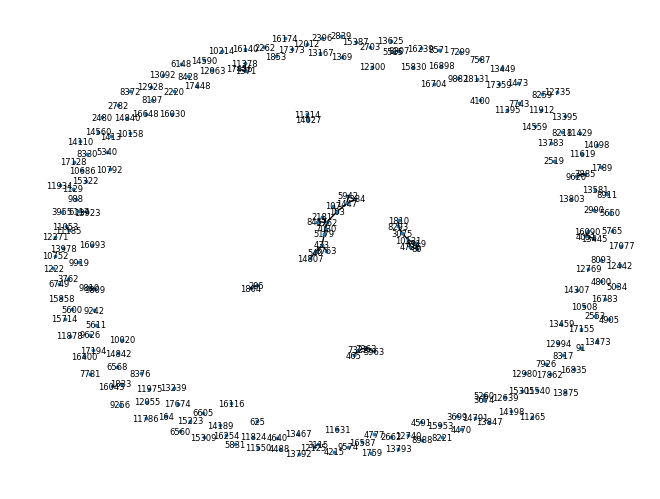

In [64]:
nodelist = symbol_pep_54
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_54")  
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_54_relayout")  

In [65]:
nodelist = symbol_pep_63
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name= "symbol_pep_63")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_63_relayout")

C_DEBUG: sub_nodes: ['IQGAP2', 'SMYD3', 'SSR1', 'SUMF2', 'TXNIP', 'CYBRD1', 'PAF1', 'SETDB2', 'IRF2', 'XBP1', 'MRFAP1', 'ST8SIA1', 'USP32', 'MYO1D', 'ETFBKMT', 'QSER1', 'SNRNP200', 'KDM5D', 'UBN1', 'KAT6B', 'USP25', 'ZNF331', 'MR1', 'YWHAQ', 'ATN1', 'BAZ2A', 'RABL3', 'KLF11', 'HIVEP2', 'TARBP2', 'EIF3F', 'FAM13C', 'RRP36', 'ANTKMT', 'ZBTB21', 'OSBPL11', 'SLC6A6', 'SLC37A2', 'ZNF324', 'HSPB8', 'CD2BP2-DT', 'JUN-DT', 'KDM6A', 'RPS18', 'PTGIS', 'ERCC4', 'NID2', 'ZNF200', 'GALE', 'KLHL25', 'MAN1B1', 'CYP3A5', 'DGLUCY', 'PHC2', 'RFTN1', 'FUT11', 'MRC2', 'AXL', 'SLC25A13', 'ESR1', 'DENND10', 'UBB', 'USP3', 'FZD1', 'MIATNB', 'ECM1', 'FOXO3', 'DCAF11', 'GOLGA2P10', 'DLG1', 'FCHO2', 'GPR155', 'ELN', 'MAP3K20', 'EEIG2', 'SRP9', 'METAP2', 'UTP4', 'RHOC', 'DCTD', 'SLAMF6', 'CRYZL2P', 'SLC38A6', 'GPR132', 'CHD7', 'RAB33B-AS1', 'PDE12', 'PDE12', 'SLC26A2', 'MAPRE1', 'EXOC8', 'ATL2', 'OAT', 'ATMIN', 'ARHGAP19', 'S1PR1', 'RPL38', 'FUCA1', 'OTUD4', 'IL16', 'SEL1L3', 'OGDHL', 'CLN5', 'MRPL55', 'ECM2', '

C_DEBUG: sub_nodes: ['CDCA5', 'SPSB2', 'SPSB2', 'KIF2C', 'BTG3', 'MYBL2', 'ESCO2', 'SLC1A5', 'MPP2', 'ACAT2', 'SLC30A10', 'CCNA2', 'MAL2', 'GINS3', 'HOXB13', 'KRT18', 'MARVELD2', 'H3C10', 'SGO1', 'KIF11', 'POMK', 'NCAPD2', 'H1-3', 'TRIP13', 'SNORA73B', 'H2AC20', 'GAN', 'NELL2', 'CCNB2', 'CDC20', 'F2RL1', 'FOXA1', 'FBN2', 'GFI1', 'DNAH14', 'MCM10', 'TROAP', 'E2F2', 'CCNB1', 'H1-4', 'ESRP2', 'H4C2', 'BUB1B', 'BUB1', 'HOXD10', 'H4C4', 'DSC3', 'RAB3B', 'GAS2L3', 'H3C2', 'EFNA5', 'RAB3GAP1', 'TRIM59', 'MAP7', 'LRRC75A', 'STK26', 'TICRR', 'PTTG1', 'RIPK4', 'SHROOM3', 'COCH', 'RHPN2', 'HACD3', 'SALL1', 'HOXB9', 'ORC1', 'MAD2L1', 'ZNF850', 'CDK1', 'APLP1', 'RN7SL3', 'KIF18B', 'KRT8', 'FOXM1', 'CDC45', 'RENO1', 'NEFL', 'DEPDC1B', 'H4C5', 'PIMREG', 'SLC27A5', 'SFXN2', 'CAMSAP3', 'NR6A1', 'EPCAM', 'CDC25C', 'CDS1', 'GTSE1', 'FLG', 'SCARNA5', 'EXO1', 'PRAME', 'NCR3LG1', 'ZWINT', 'HOOK1', 'PLK1', 'PCDH7', 'BIRC5', 'FGFR2', 'SAPCD2', 'CCNE2', 'NEK2', 'DMKN', 'GNG4', 'SNORD17', 'SCML2', 'RN7SL1', 'KI

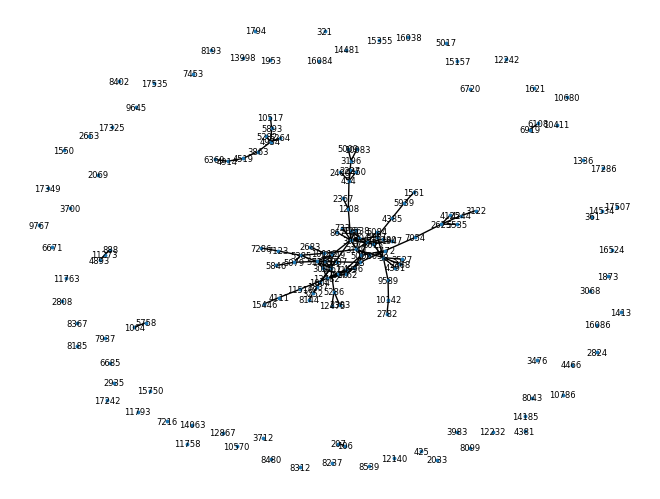

In [66]:
nodelist = symbol_pep_66
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_66")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_66_relayout")

C_DEBUG: sub_nodes: ['TRIM25', 'DNER', 'SAMD5', 'CCN4', 'VWCE', 'ITGA10', 'ANKMY1', 'EFR3A', 'F2R', 'TOX2', 'NIF3L1', 'ARRDC1-AS1', 'GRPEL1', 'EPB41L4A-AS1', 'LRMDA', 'GALNT7', 'SLC4A1AP', 'LINC02984', 'SLC9A5', 'MRAP2', 'SAT2', 'FOXN2', 'TIPIN', 'CHASERR', 'SCIMP', 'TTC13', 'QRICH2', 'SNAPC4', 'RASGEF1A', 'TVP23C', 'ZNF614', 'NUDT1', 'RUFY1', 'OGFRL1', 'METTL17', 'CDCA4', 'ZNF618', 'GRIN2A', 'CLN6', 'ZNF568', 'CILP2', 'GNB1L', 'FMOD', 'ADA2', 'CACNA1D', 'CPM', 'UBA1', 'COL11A1', 'ZFAT', 'GALNT11', 'ARHGEF10', 'C1orf35', 'CD22', 'CYP2R1', 'GAS5', 'RTN4RL1', 'ZNF420', 'AGO4', 'COL22A1', 'TRAPPC3', 'SMYD4', 'ASL', 'PCSK1N', 'FAM110A', 'EIF2B5', 'DDX41', 'DUSP4', 'BEND7', 'NUFIP1', 'NSDHL', 'SNHG7', 'SNHG7', 'TRAP1', 'SLC22A15', 'MAB21L2', 'PPP1R3G', 'PEX7', 'METAP1D', 'SLC25A37', 'POLD3', 'LINC02432', 'SAMD11', 'APP', 'MEOX1', 'ADAMTS6', 'SFR1', 'METAP1', 'RELN', 'STAC', 'LSAMP', 'TRAPPC2L', 'ZNF880', 'PLEKHA5', 'RFC2', 'PPP1CC', 'UQCRHL', 'ZNF383', 'ZFP91', 'SERP2', 'F2RL2', 'ZNF496', '

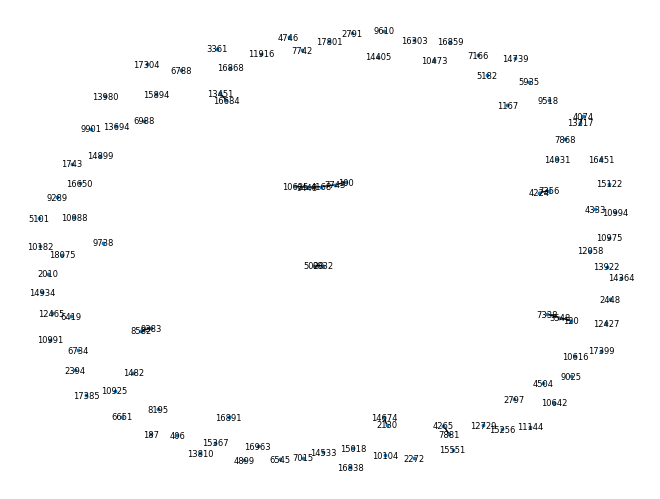

In [67]:
nodelist = symbol_pep_69
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_69")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_69_relayout")

C_DEBUG: sub_nodes: ['CLDN10', 'IL18BP', 'CXCL11', 'TENT5C', 'HLA-DPB1', 'TNFRSF17', 'ELMOD1', 'GSTO2', 'CARMIL2', 'SEPTIN1', 'KY', 'PIK3CD', 'IGKV3-15', 'CD8A', 'MRPS30-DT', 'HCLS1', 'IKZF3', 'SAMSN1', 'CD2', 'GAN', 'LILRB2', 'EAF2', 'IGLV3-9', 'PPIL6', 'WASL-DT', 'AOC3', 'HMGN4', 'PLA2G2D', 'GPR12', 'FAM13C', 'CD274', 'IFI6', 'TAGAP', 'RNF128', 'CYRIB', 'CYBA', 'IGHG4', 'IL21R', 'PYGL', 'UCP2', 'HLA-DRB1', 'PTGIS', 'DERL3', 'LINC00861', 'OSR1', 'MAGI1', 'PCED1B-AS1', 'NRXN1', 'MAOA', 'PAIP2B', 'PHYHIP', 'NDUFA10', 'FGF14', 'CORO1A', 'SIT1', 'IL12RB1', 'UBE2L6', 'PLEKHF2', 'MYRIP', 'PRF1', 'SSC5D', 'COL22A1', 'ARPC3', 'SLC9A2', 'IGKV1-5', 'IGLV4-69', 'FRY', 'GAREM1', 'CD38', 'IGLV8-61', 'SLAMF6', 'RNF180', 'PARD3B', 'RPH3AL', 'IGHV4-4', 'CD8B', 'MAP4K1', 'SYNPO2', 'SLAMF7', 'ARHGAP9', 'CLSTN2', 'NKRF', 'CGAS', 'IGLV3-21', 'KRT10-AS1', 'TNFRSF21', 'SPP1', 'SLA2', 'IGKV2D-29', 'IGLV3-25', 'PCDH19', 'SEL1L3', 'IGHV3-43', 'APOL1', 'SERPINB9', 'SEMA4D', 'IGHV4-31', 'PRELP', 'PAMR1', 'IGHV1

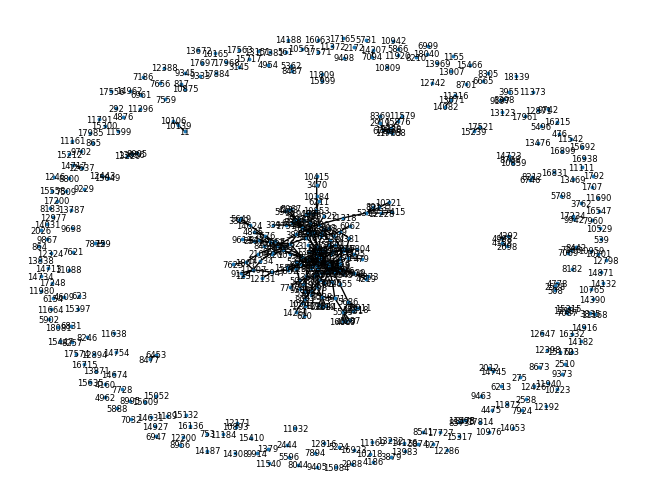

In [68]:
nodelist = symbol_pep_71
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_71")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_71_relayout")

C_DEBUG: sub_nodes: ['COMMD7', 'BCAS2', 'SLC29A3']
C_DEBUG: sub_nodes_ids: [7217, 11498, 17430]
C_DEBUG: subgraph number of edges: 0
None {7217: Text(-0.7158197198205725, -0.5679129530694484, '7217'), 11498: Text(0.876135696300737, -0.43208704693055167, '11498'), 17430: Text(-0.16031597648016457, 1.0, '17430')}


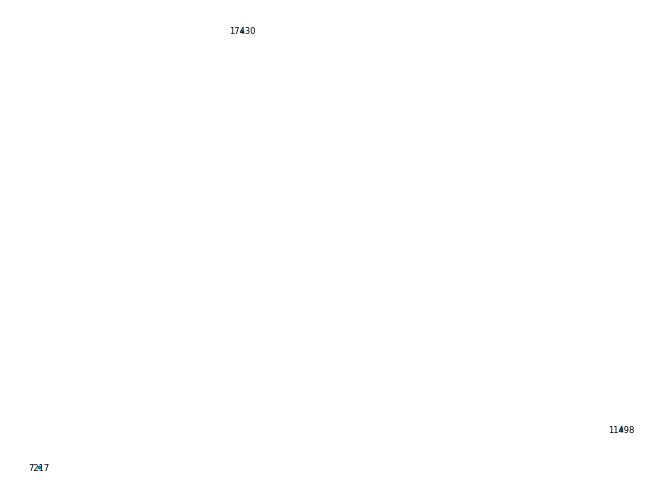

In [69]:
nodelist = symbol_pep_72
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_72")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_72_relayout")

C_DEBUG: sub_nodes: ['AIF1L', 'MT-ND5', 'AP1AR', 'BOLA1', 'JCAD', 'SLC1A5', 'RNF150', 'ALDH16A1', 'BLOC1S4', 'LY86', 'SHE', 'TMEM70', 'RSAD1', 'COBLL1', 'LINC02210', 'COX8A', 'ALKBH2', 'ADPRH', 'MR1', 'TIMM10', 'DHRS1', 'ATP5MC3', 'TBX2', 'NEDD8', 'ITGA1', 'GSTO1', 'ZNF672', 'ZBTB43', 'TRIM47', 'EIF2B2', 'FZD7', 'MT-CYB', 'MT-ND4', 'NANS', 'DDIT4L', 'ACP5', 'PALMD', 'SLC37A2', 'MT-ND2', 'CIAO3', 'BLTP1', 'C11orf71', 'SERGEF', 'DRAM2', 'CARMN', 'MT-CO2', 'BIRC6', 'MT-CO3', 'KLHL13', 'NBAS', 'GATA2', 'PPFIBP1', 'MRPS26', 'POGLUT1', 'TRPM6', 'MACROD1', 'RGS5', 'MECOM', 'ABCG2', 'TJP1', 'PTPRB', 'TMEM220', 'COG8', 'ZDHHC4', 'MT-RNR2', 'TYSND1', 'MT-CO1', 'GTPBP3', 'CD200', 'MAGEF1', 'ACP6', 'FILIP1', 'MT-ND4L', 'ABCB1', 'TPTEP1', 'TAFAZZIN', 'FLNB', 'OXLD1', 'LYSMD2', 'RPS27L', 'RP2', 'TNS1', 'ECRG4', 'NDUFB1', 'MST1', 'HDHD3', 'NEIL1', 'FHL5', 'COX5A', 'RGS10', 'ABCA8', 'LEPR', 'MCRIP2', 'CMTM3', 'FCGR2B', 'ELP5', 'TMEM267', 'C1D', 'ZNF273', 'DENND2D', 'MT-ND6', 'PSENEN', 'CEP43', 'TSPAN6

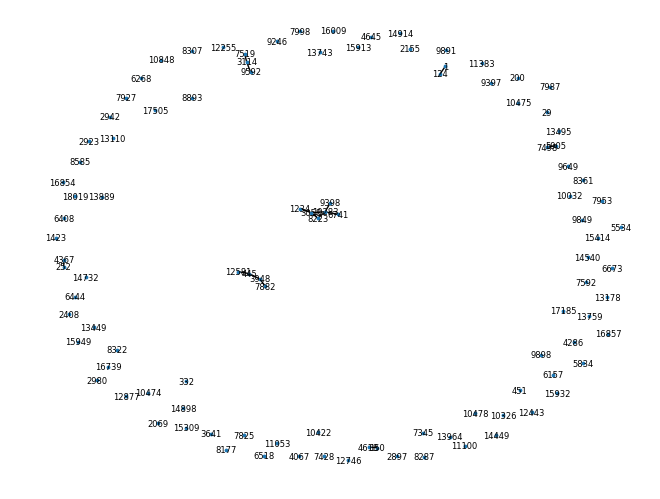

✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main


In [70]:
nodelist = symbol_pep_75
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, scene_name = "symbol_pep_75")
#tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, scene_name= "symbol_pep_75_relayout")

In [ ]:
session.reload_project() # to get back to initial state of project (incl. initial layout)